In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import random
import zipfile
from collections import Counter

import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

import torch
import torch.nn as nn
import torchvision.transforms.functional as TF
from torchvision import transforms, models
from torch.utils.data import Dataset, DataLoader
!pip install grad-cam captum --quiet

from captum.attr import IntegratedGradients, NoiseTunnel

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import BinaryClassifierOutputTarget

from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    recall_score, precision_score, f1_score,
    roc_auc_score, roc_curve, auc,
    confusion_matrix, ConfusionMatrixDisplay
)

# **PREPROCESSING**

In [ ]:
zip_path = "/content/drive/MyDrive/DETECCION DE FRACTURAS.zip"
extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset uploaded")

Dataset uploaded


In [ ]:
DATASET_ROOT="/content/dataset/DETECCION DE FRACTURAS"
TRAIN_IMG_DIR="/content/dataset/DETECCION DE FRACTURAS/train/images"
TRAIN_LABEL_DIR="/content/dataset/DETECCION DE FRACTURAS/train/labels"
VALID_IMG_DIR="/content/dataset/DETECCION DE FRACTURAS/valid/images"
VALID_LABEL_DIR="/content/dataset/DETECCION DE FRACTURAS/valid/labels"
TEST_IMG_DIR="/content/dataset/DETECCION DE FRACTURAS/test/images"
TEST_LABEL_DIR="/content/dataset/DETECCION DE FRACTURAS/test/labels"

In [ ]:
device= "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

Device: cuda


In [ ]:
class WristXrayDataset(Dataset):

    def __init__(self, img_dir, label_dir, transform=None):
        self.img_dir   = img_dir
        self.label_dir = label_dir
        self.transform = transform
        self.filenames = sorted(os.listdir(img_dir))

        self.labels = []
        for fname in self.filenames:
            txt_name = os.path.splitext(fname)[0] + ".txt" 
            txt_path = os.path.join(label_dir, txt_name)

            label = 0
            if os.path.exists(txt_path):
                with open(txt_path, "r") as f:
                    for line in f.readlines():
                        classe = int(line.strip().split()[0])
                        if classe == 0:
                            label = 1
                            break
            self.labels.append(label)

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.filenames[idx])
        image    = Image.open(img_path).convert("RGB")
        label    = self.labels[idx]
        if self.transform:
            image = self.transform(image)
        return image, label, img_path

In [ ]:
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.GaussianBlur(kernel_size=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD)
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD)
])

train_dataset = WristXrayDataset(TRAIN_IMG_DIR, TRAIN_LABEL_DIR, transform=train_transform)
valid_dataset = WristXrayDataset(VALID_IMG_DIR, VALID_LABEL_DIR, transform=val_test_transform)
test_dataset  = WristXrayDataset(TEST_IMG_DIR,  TEST_LABEL_DIR,  transform=val_test_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=2)
valid_loader = DataLoader(valid_dataset, batch_size=32, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False, num_workers=2)

print(f"Train: {len(train_dataset)} images")
print(f"Valid: {len(valid_dataset)} images")
print(f"Test:  {len(test_dataset)} images")

Train: 14216 images
Valid: 4063 images
Test:  2030 images


# **TRAINING**

## ResNet50 Model

In [ ]:
MODEL_PATH = "/content/drive/MyDrive/best_model_resnet50_colab.pth"

if os.path.exists(MODEL_PATH):
    print("Model already trained found")
    model = models.resnet50(pretrained=False)
    model.fc = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(model.fc.in_features, 1)
    )
    model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
    model = model.to(device)
    model.eval()
    print("Model uploaded")

else:
    print("Model not found — starting training")
    model = models.resnet50(pretrained=True)
    model.fc = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(model.fc.in_features, 1)
    )
    model = model.to(device)

    n_pos = sum(train_dataset.labels)
    n_neg = len(train_dataset.labels) - n_pos
    pos_weight = torch.tensor([n_neg / max(n_pos, 1)], dtype=torch.float32).to(device)
    print(f"pos_weight = {pos_weight.item():.4f}  (neg={n_neg}, pos={n_pos})")
    criterion  = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    optimizer = torch.optim.Adam([
        {"params": model.layer1.parameters(), "lr": 1e-5, "weight_decay": 1e-4},
        {"params": model.layer2.parameters(), "lr": 1e-5, "weight_decay": 1e-4},
        {"params": model.layer3.parameters(), "lr": 1e-4, "weight_decay": 1e-4},
        {"params": model.layer4.parameters(), "lr": 1e-4, "weight_decay": 1e-4},
        {"params": model.fc.parameters(),     "lr": 1e-3, "weight_decay": 1e-4},
    ])

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3)

    NUM_EPOCHS=30
    PATIENCE=5
    best_val_loss=float("inf")
    epochs_no_improve =0
    train_losses=[]
    val_losses=[]

    for epoch in range(NUM_EPOCHS):

        model.train()
        running_loss = 0.0

        for images, labels, _ in train_loader:
            images = images.to(device)
            labels = labels.float().unsqueeze(1).to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss    = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        train_loss = running_loss / len(train_loader)

        model.eval()
        val_loss = 0.0

        with torch.no_grad():
            for images, labels, _ in valid_loader:
                images = images.to(device)
                labels = labels.float().unsqueeze(1).to(device)
                outputs = model(images)
                loss    = criterion(outputs, labels)
                val_loss += loss.item()

        val_loss = val_loss / len(valid_loader)

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss     = val_loss
            epochs_no_improve = 0
            torch.save(model.state_dict(), MODEL_PATH)
            print(f"Epoch {epoch+1:02d} → train: {train_loss:.4f}  val: {val_loss:.4f} saved")
        else:
            epochs_no_improve += 1
            print(f"Epoch {epoch+1:02d} → train: {train_loss:.4f}  val: {val_loss:.4f}  (no improve: {epochs_no_improve}/{PATIENCE})")

            if epochs_no_improve == PATIENCE:
                print(f"\nEarly stopping at epoch {epoch+1}")
                break



Model already trained found
Model uploaded


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


In [ ]:
train_losses = [0.2492, 0.1774, 0.1599, 0.1520, 0.1404, 0.1348, 0.1307, 0.1230, 0.1205, 0.1196, 0.1139, 0.1112, 0.0900]
val_losses= [0.1728, 0.1887, 0.1486, 0.1392, 0.1331, 0.1462, 0.1264, 0.1226, 0.1404, 0.1296, 0.1560, 0.1269, 0.1260]

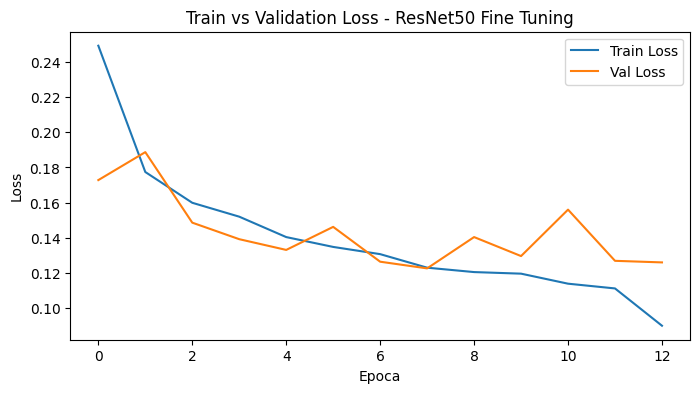

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses,   label="Val Loss")
plt.xlabel("Epoca")
plt.ylabel("Loss")
plt.title("Train vs Validation Loss - ResNet50 Fine Tuning")
plt.legend()
plt.show()

## Evaluation

In [ ]:
model.eval()

all_labels = []
all_preds  = []
all_probs  = []

with torch.no_grad():
    for images, labels, _ in test_loader:
        images = images.to(device)
        labels = labels.float().unsqueeze(1).to(device)

        outputs = model(images)
        probs   = torch.sigmoid(outputs)
        preds   = (probs > 0.5).float()

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

all_labels = np.array(all_labels).reshape(-1)
all_preds  = np.array(all_preds).reshape(-1)
all_probs  = np.array(all_probs).reshape(-1)

In [ ]:
accuracy = accuracy_score(all_labels, all_preds)
balanced_acc = balanced_accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds)
recall = recall_score(all_labels, all_preds, pos_label=1)
specificity = recall_score(all_labels, all_preds, pos_label=0)
f1 = f1_score(all_labels, all_preds)
fpr, tpr, _ = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

print(f"Accuracy          : {accuracy:.4f}")
print(f"Balanced Accuracy : {balanced_acc:.4f}")
print(f"Precision         : {precision:.4f}")
print(f"Recall (Fracture) : {recall:.4f}")
print(f"Specificity       : {specificity:.4f}")
print(f"F1 Score          : {f1:.4f}")
print(f"AUC               : {roc_auc:.4f}")

Accuracy          : 0.9305
Balanced Accuracy : 0.9277
Precision         : 0.9583
Recall (Fracture) : 0.9363
Specificity       : 0.9191
F1 Score          : 0.9472
AUC               : 0.9792


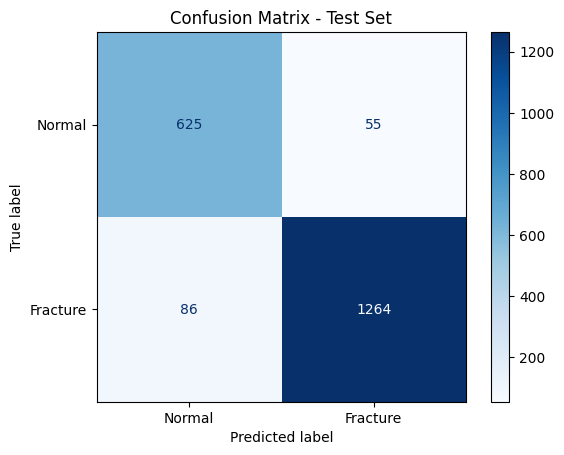

In [ ]:
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal", "Fracture"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Test Set")
plt.show()

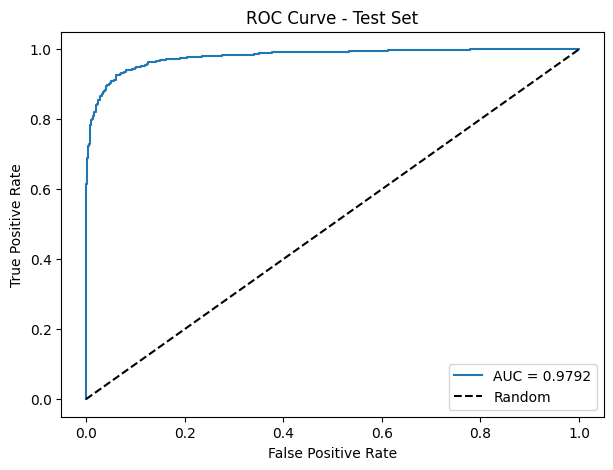

In [ ]:
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Test Set")
plt.legend()
plt.show()

# **GRADCAM AND INTEGRATED GRADIENTS**

In [ ]:
GRADCAM_DIR = "/content/gradcam_results"
IG_DIR = "/content/ig_results"
os.makedirs(GRADCAM_DIR, exist_ok=True)
os.makedirs(IG_DIR,      exist_ok=True)
gradcam_files = os.listdir("/content/gradcam_results")
ig_files = os.listdir("/content/ig_results")

In [ ]:
target_layer = model.layer4[-1]

cam = GradCAM(
    model=model,
    target_layers=[target_layer]
)

In [ ]:
ig = IntegratedGradients(model)

In [ ]:
torch.cuda.empty_cache()

test_loader_small = DataLoader(test_dataset, batch_size=4, shuffle=False, num_workers=2)

model.eval()

for batch_idx, (images, labels, paths) in enumerate(test_loader_small):

    images = images.to(device)
    labels = labels.float().to(device)

    outputs = model(images)
    probs   = torch.sigmoid(outputs).squeeze(1)
    preds   = (probs > 0.5).float()

    for i in range(images.size(0)):

        input_tensor = images[i].unsqueeze(0)
        prob  = probs[i].item()
        pred  = int(preds[i].item())
        label = int(labels[i].item())

        target        = BinaryClassifierOutputTarget(pred)
        grayscale_cam = cam(input_tensor=input_tensor, targets=[target])[0]

        img = input_tensor.squeeze().cpu().numpy().transpose(1, 2, 0)
        img = img * np.array(STD) + np.array(MEAN)
        img = np.clip(img, 0, 1)

        visualization = show_cam_on_image(img.astype(np.float32), grayscale_cam, use_rgb=True)

        if pred == 1 and label == 1:
            case = "TP"
        elif pred == 1 and label == 0:
            case = "FP"
        elif pred == 0 and label == 0:
            case = "TN"
        else:
            case = "FN"

        if case in ["FP", "FN"]:
            filename = f"{case}_prob{prob:.2f}_{os.path.basename(paths[i])}"
            cv2.imwrite(
                os.path.join(GRADCAM_DIR, filename),
                cv2.cvtColor(visualization, cv2.COLOR_RGB2BGR)
            )


    baseline = torch.zeros_like(images).to(device)
    attributions = ig.attribute(
        images,
        baselines=baseline,
        target=0,
        n_steps=15
    )
    attributions = attributions.detach().cpu().numpy()


    torch.cuda.empty_cache()

    for i in range(images.size(0)):

        prob  = probs[i].item()
        pred  = int(preds[i].item())
        label = int(labels[i].item())

        if pred == label:
            continue

        img = images[i].cpu().numpy().transpose(1, 2, 0)
        img = img * np.array(STD) + np.array(MEAN)
        img = np.clip(img, 0, 1)

        attr    = attributions[i].transpose(1, 2, 0)
        attr    = np.mean(np.abs(attr), axis=2)
        max_val = attr.max()
        if max_val > 0:
            attr = attr / max_val

        fig, ax = plt.subplots(figsize=(4, 4))
        ax.imshow(img)
        ax.imshow(attr, cmap="jet", alpha=0.5)
        ax.axis("off")
        ax.set_title(f"Prob:{prob:.2f} Pred:{pred} True:{label}")

        base      = os.path.splitext(os.path.basename(paths[i]))[0]
        save_name = f"IG_pred{pred}_true{label}_prob{prob:.2f}_{base}.png"
        fig.savefig(os.path.join(IG_DIR, save_name), bbox_inches="tight", dpi=150)
        plt.close(fig)

    if batch_idx % 50 == 0:
        print(f"Batch {batch_idx}/{len(test_loader_small)} completed")
print("Completed")

Batch 0/508 completed
Batch 50/508 completed
Batch 100/508 completed
Batch 150/508 completed
Batch 200/508 completed
Batch 250/508 completed
Batch 300/508 completed
Batch 350/508 completed
Batch 400/508 completed
Batch 450/508 completed
Batch 500/508 completed
Completed


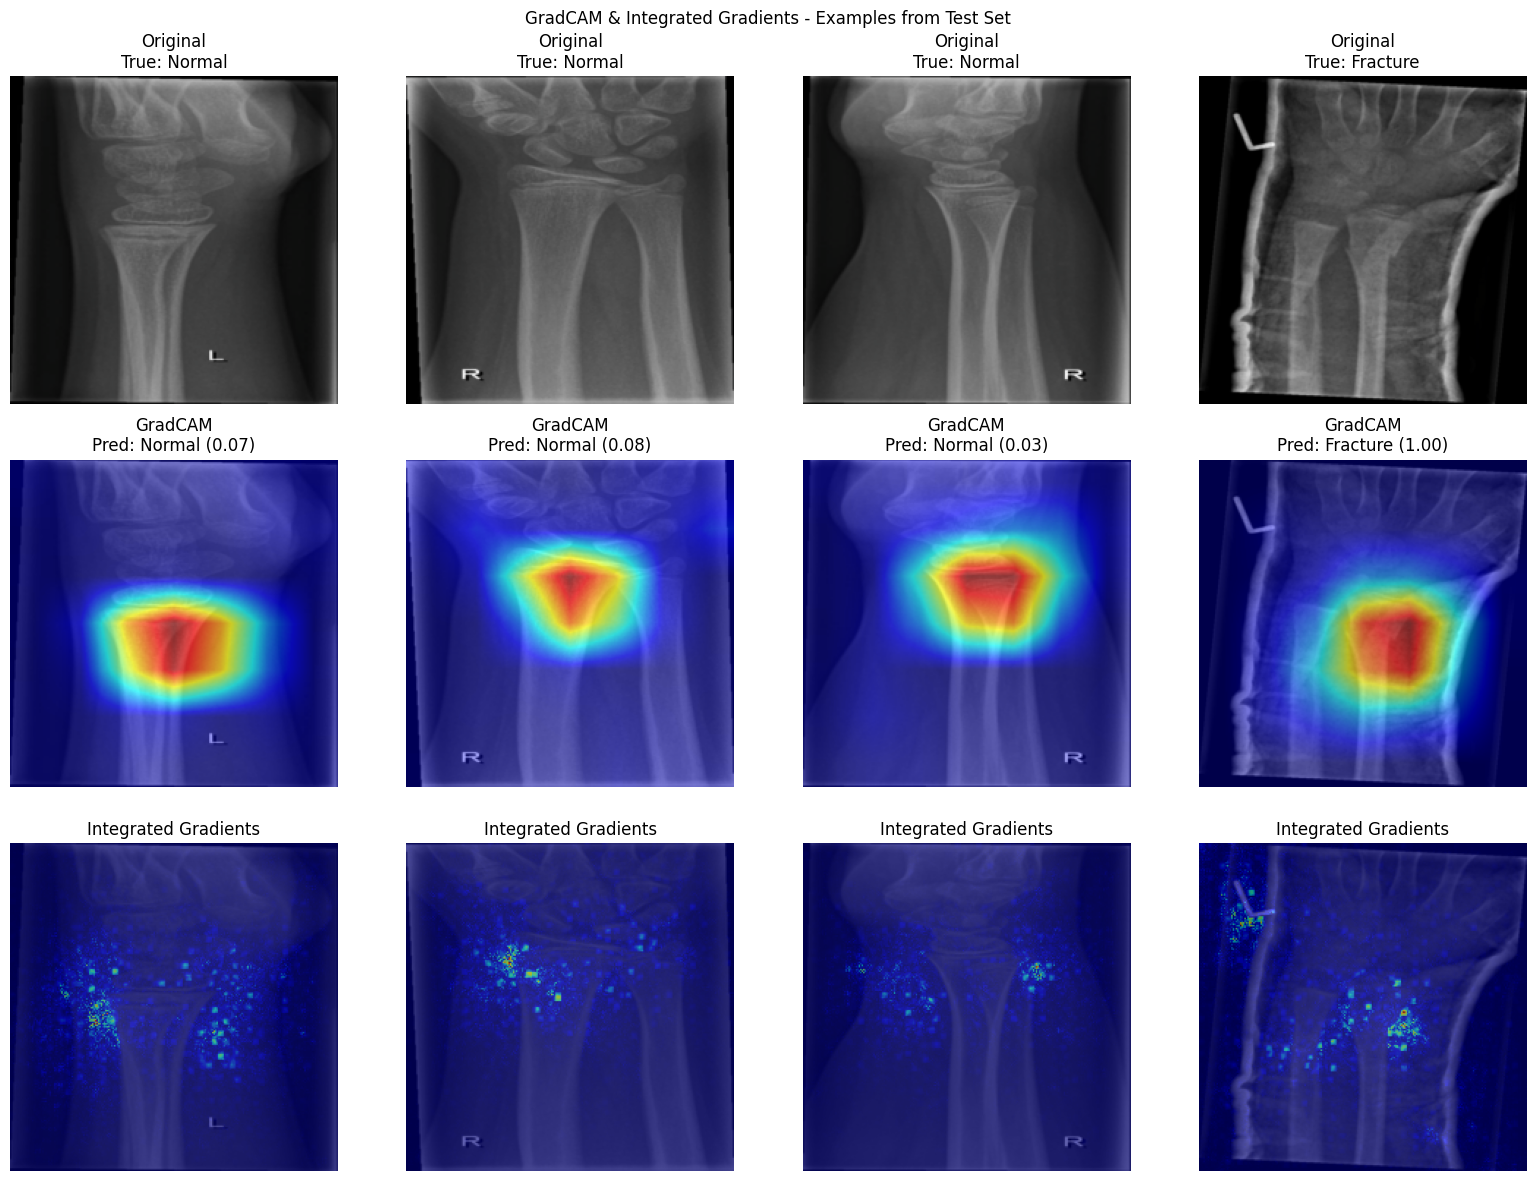

In [ ]:
model.eval()
images, labels, paths = next(iter(test_loader))
images = images.to(device)
labels = labels.float().to(device)

outputs = model(images)
probs   = torch.sigmoid(outputs).squeeze(1)
preds   = (probs > 0.5).float()

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
fig.suptitle("GradCAM & Integrated Gradients - Examples from Test Set")

for i in range(4):
    input_tensor = images[i].unsqueeze(0)
    pred         = int(preds[i].item())
    label        = int(labels[i].item())
    prob         = probs[i].item()


    grayscale_cam = cam(input_tensor=input_tensor, targets=[BinaryClassifierOutputTarget(pred)])[0]

    img = input_tensor.squeeze().cpu().numpy().transpose(1, 2, 0)
    img = img * np.array(STD) + np.array(MEAN)
    img = np.clip(img, 0, 1)

    visualization = show_cam_on_image(img.astype(np.float32), grayscale_cam, use_rgb=True)

    baseline     = torch.zeros_like(input_tensor).to(device)
    attributions = ig.attribute(input_tensor, baselines=baseline, target=0, n_steps=15)
    attr = attributions.squeeze().cpu().detach().numpy().transpose(1, 2, 0)
    attr = np.abs(attr).sum(axis=2)
    attr = (attr - attr.min()) / (attr.max() - attr.min() + 1e-8)

    axes[0, i].imshow(img)
    axes[0, i].set_title(f"Original\nTrue: {'Fracture' if label==1 else 'Normal'}")
    axes[0, i].axis("off")

    axes[1, i].imshow(visualization)
    axes[1, i].set_title(f"GradCAM\nPred: {'Fracture' if pred==1 else 'Normal'} ({prob:.2f})")
    axes[1, i].axis("off")

    axes[2, i].imshow(img)
    axes[2, i].imshow(attr, cmap="jet", alpha=0.6)
    axes[2, i].set_title("Integrated Gradients")
    axes[2, i].axis("off")

torch.cuda.empty_cache()
plt.tight_layout()
plt.show()

## Improved Integrated Gradients


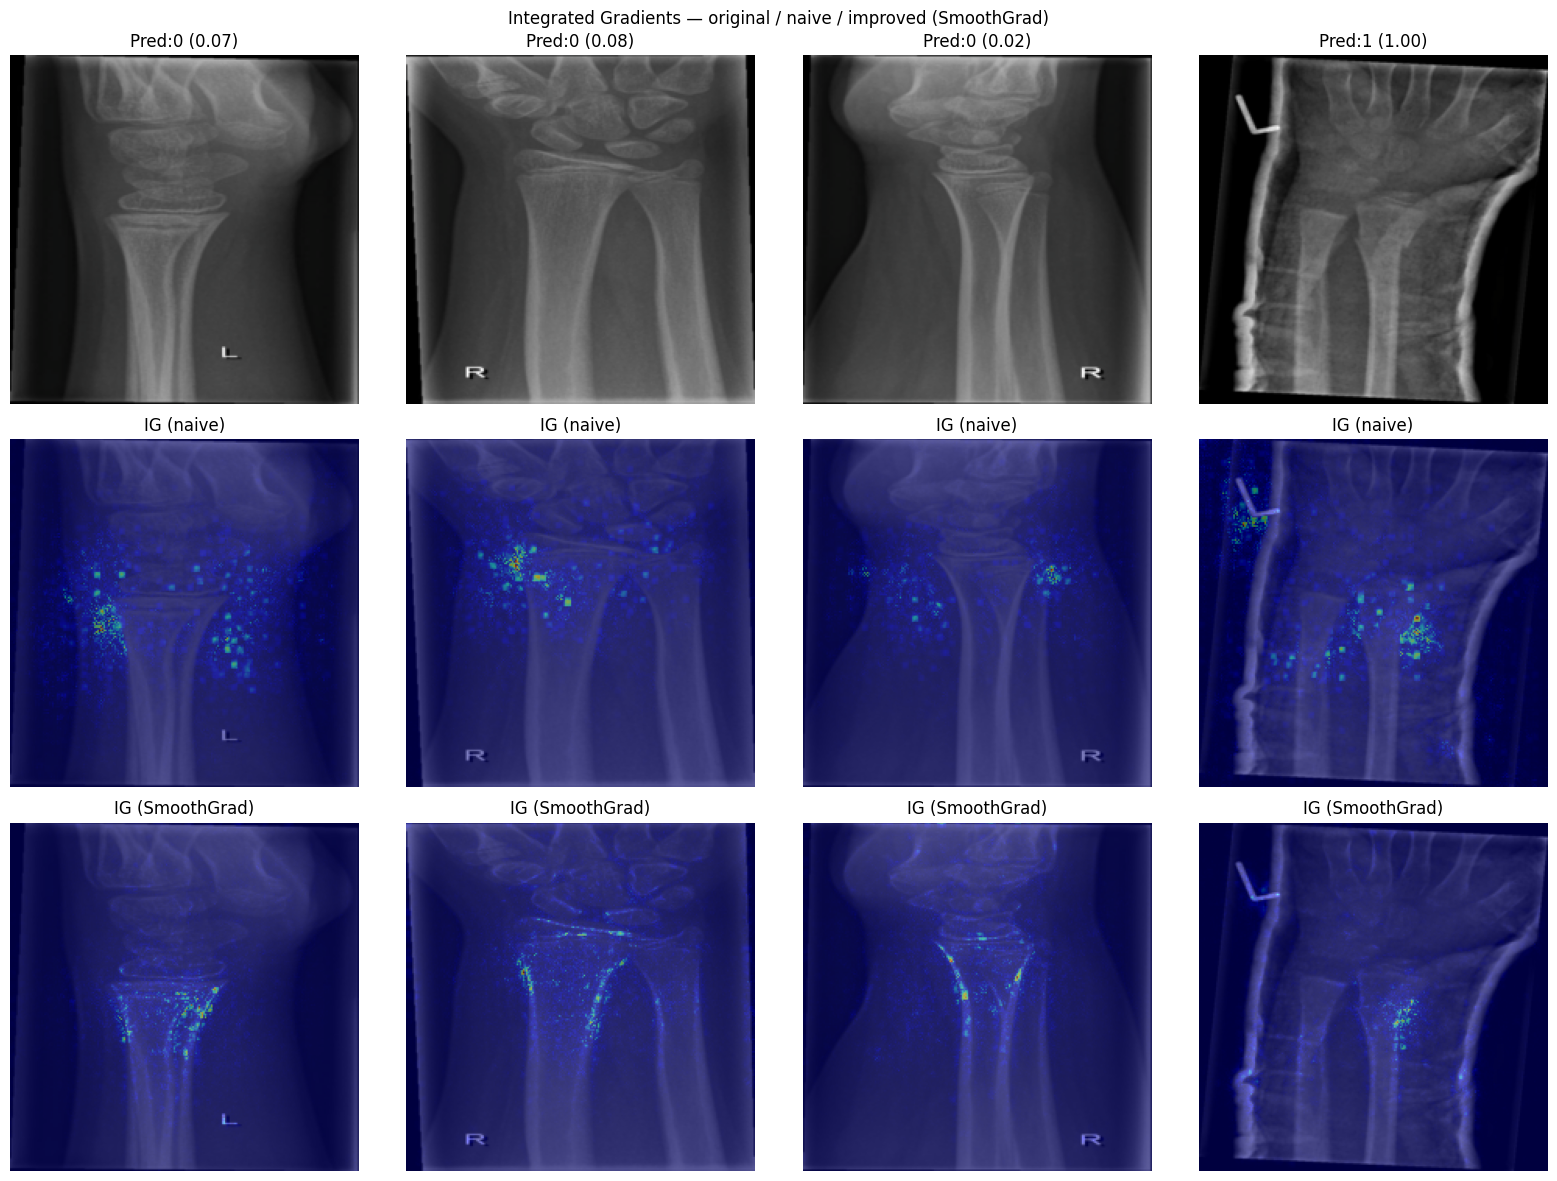

In [ ]:
ig = IntegratedGradients(model)
nt = NoiseTunnel(ig)

def blurred_baseline(x, sigma=7):
    return TF.gaussian_blur(x, kernel_size=[15, 15], sigma=sigma)

def improved_ig(x, pred, n_steps=20, n_samples=4, sample_bs=1):
    torch.cuda.empty_cache()
    attr = nt.attribute(
        x, nt_type="smoothgrad",
        nt_samples=n_samples, nt_samples_batch_size=sample_bs, stdevs=0.1,
        baselines=blurred_baseline(x), target=0, n_steps=n_steps,
        internal_batch_size=sample_bs * n_steps,
    )
    if pred == 0:
        attr = -attr
    a = np.mean(np.abs(attr.squeeze().cpu().detach().numpy().transpose(1, 2, 0)), axis=2)
    if a.max() > 0:
        a = a / a.max()
    del attr
    torch.cuda.empty_cache()
    return a

def naive_ig(x):
    torch.cuda.empty_cache()
    att = ig.attribute(x, baselines=torch.zeros_like(x), target=0,
                       n_steps=20, internal_batch_size=10)
    a = np.mean(np.abs(att.squeeze().cpu().detach().numpy().transpose(1, 2, 0)), axis=2)
    if a.max() > 0:
        a = a / a.max()
    del att
    torch.cuda.empty_cache()
    return a

model.eval()
images, labels, paths = next(iter(test_loader))

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
fig.suptitle("Integrated Gradients — original / naive / improved (SmoothGrad)")

for j in range(4):
    x = images[j].unsqueeze(0).to(device)
    with torch.no_grad():
        prob = torch.sigmoid(model(x)).item()
    pred = 1 if prob > 0.5 else 0
    img = np.clip(images[j].cpu().numpy().transpose(1, 2, 0) * np.array(STD) + np.array(MEAN), 0, 1)

    try:
        naive = naive_ig(x)
        imp = improved_ig(x, pred)
        ok = True
    except torch.cuda.OutOfMemoryError:
        torch.cuda.empty_cache()
        ok = False
        print(f"OOM on image {j} — skipped")

    axes[0, j].imshow(img); axes[0, j].set_title(f"Pred:{pred} ({prob:.2f})"); axes[0, j].axis("off")
    if ok:
        axes[1, j].imshow(img); axes[1, j].imshow(naive, cmap="jet", alpha=0.5)
        axes[1, j].set_title("IG (naive)"); axes[1, j].axis("off")
        axes[2, j].imshow(img); axes[2, j].imshow(imp, cmap="jet", alpha=0.5)
        axes[2, j].set_title("IG (SmoothGrad)"); axes[2, j].axis("off")
    else:
        axes[1, j].axis("off"); axes[2, j].axis("off")

plt.tight_layout()
plt.show()

# **MEDCLIP**

## Import MEDCLIP

In [ ]:
print(torch.__version__)
print(torch.cuda.is_available())


2.11.0+cu128
True


In [ ]:
!pip install medclip

In [ ]:
!pip install transformers>=4.18.0
!pip install torch torchvision
!pip install Pillow
!pip install scikit-learn
!pip install numpy
!pip install pandas
!pip install tqdm
!pip install huggingface_hub

In [ ]:
import transformers
from transformers import CLIPImageProcessor

if not hasattr(transformers, 'CLIPFeatureExtractor'):
    transformers.CLIPFeatureExtractor = CLIPImageProcessor
    print("Alias CLIPFeatureExtractor set correctly.")
else:
    print("Alias CLIPFeatureExtractor already set correctly.")

from medclip import MedCLIPModel, MedCLIPVisionModelViT, MedCLIPVisionModel
from medclip import MedCLIPProcessor
print("MedCLIP imported correctly")

Alias CLIPFeatureExtractor already set correctly.
MedCLIP imported correctly


In [ ]:
if not hasattr(transformers, 'CLIPFeatureExtractor'):
    transformers.CLIPFeatureExtractor = CLIPImageProcessor

import torch, os, zipfile, urllib.request
from medclip import MedCLIPModel, MedCLIPVisionModelViT

URL      = "https://storage.googleapis.com/pytrial/medclip-vit-pretrained.zip"
zip_path = "/tmp/medclip-vit-pretrained.zip"
ext_path = "/tmp/medclip-vit-pretrained"

if not os.path.exists(zip_path):
    urllib.request.urlretrieve(URL, zip_path)
if not os.path.exists(ext_path):
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall(ext_path)

ckpt = next(
    os.path.join(r, f)
    for r, _, files in os.walk(ext_path)
    for f in files if f.endswith(('.bin', '.pt', '.pth'))
)

model_medclip = MedCLIPModel(vision_cls=MedCLIPVisionModelViT)
state_dict = torch.load(ckpt, map_location="cpu")
state_dict = state_dict.get("model", state_dict.get("state_dict", state_dict))
missing, unexpected = model_medclip.load_state_dict(state_dict, strict=False)
print(f"Missing: {len(missing)} | Unexpected: {len(unexpected)}")
model_medclip.eval()
print("MedCLIP ViT uploaded")
model_medclip = model_medclip.to(device)
print("MedCLIP on:", device)

import medclip.dataset as _ds
from transformers import AutoTokenizer
import medclip

class PatchedMedCLIPProcessor:
    def __init__(self):
        self.feature_extractor = CLIPImageProcessor(
            do_resize=True,
            size={"height": 224, "width": 224},
            resample=2,
            do_center_crop=True,
            crop_size={"height": 224, "width": 224},
            do_normalize=True,
            image_mean=[0.48145466, 0.4578275, 0.40821073],
            image_std=[0.26862954, 0.26130258, 0.27577711],
            do_convert_rgb=True,
        )
        self.tokenizer = AutoTokenizer.from_pretrained("emilyalsentzer/Bio_ClinicalBERT")

    def __call__(self, text=None, images=None, return_tensors="pt", padding=True, truncation=True, max_length=77, **kwargs):
        encoding = {}
        if images is not None:
            if not isinstance(images, list):
                images = [images]
            encoding["pixel_values"] = self.feature_extractor(images=images, return_tensors=return_tensors)["pixel_values"]
        if text is not None:
            text_encoding = self.tokenizer(text, return_tensors=return_tensors, padding=padding, truncation=truncation, max_length=max_length)
            encoding.update(text_encoding)
        return encoding

_ds.MedCLIPProcessor = PatchedMedCLIPProcessor
medclip.MedCLIPProcessor = PatchedMedCLIPProcessor

processor = PatchedMedCLIPProcessor()
print("MedCLIPProcessor ready")

Loading weights:   0%|          | 0/219 [00:00<?, ?it/s]

[transformers] SwinModel LOAD REPORT from: microsoft/swin-tiny-patch4-window7-224
Key               | Status     |  | 
------------------+------------+--+-
classifier.bias   | UNEXPECTED |  | 
classifier.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Missing: 156 | Unexpected: 169
MedCLIP ViT uploaded
MedCLIP on: cuda
MedCLIPProcessor ready


## GIVEN CODE TO OPTIMIZE

In [ ]:
text_prompts = [
    "A normal wrist X-ray with no fracture",
    "A distal radius fracture is present",
    "A wrist fracture with cortical disruption",
    "No visible bone abnormality",
    "Fracture in the distal radius region"
]

_text_embed_cache = {}

def _get_text_embeds(prompts):
    key = tuple(prompts)
    if key not in _text_embed_cache:
        enc = processor(text=list(prompts), return_tensors="pt", padding=True)
        enc = {k: v.to(device) for k, v in enc.items()}
        with torch.no_grad():
            temb = model_medclip.encode_text(enc["input_ids"], enc["attention_mask"])
        _text_embed_cache[key] = temb
    return _text_embed_cache[key]

def run_medclip(image_np):
    image_pil = Image.fromarray((image_np * 255).astype(np.uint8))
    enc = processor(images=image_pil, return_tensors="pt")
    pixel_values = enc["pixel_values"].to(device)

    with torch.no_grad():
        img_embeds  = model_medclip.encode_image(pixel_values)
        text_embeds = _get_text_embeds(text_prompts)

        logits = torch.matmul(img_embeds, text_embeds.T)[0]
        probs  = torch.softmax(logits, dim=0).cpu().numpy()

    return probs

In [ ]:
all_medclip_text = []
all_medclip_conf = []

model.eval()

for batch_idx, (images, labels, paths) in enumerate(test_loader):

    images = images.to(device)
    labels = labels.float().to(device)

    with torch.no_grad():
        outputs = model(images)
        probs   = torch.sigmoid(outputs).squeeze(1)
        preds   = (probs > 0.5).float()

    for i in range(images.size(0)):

        img = images[i].cpu().numpy().transpose(1, 2, 0)
        img = img * np.array(STD) + np.array(MEAN)
        img = np.clip(img, 0, 1)

        medclip_probs = run_medclip(img)
        best_idx      = medclip_probs.argmax()

        all_medclip_text.append(text_prompts[best_idx])
        all_medclip_conf.append(medclip_probs[best_idx])

    if batch_idx % 10 == 0:
        print(f"Batch {batch_idx}/{len(test_loader)} completed")

print("MedCLIP completed")

Batch 0/64 completed
Batch 10/64 completed
Batch 20/64 completed
Batch 30/64 completed
Batch 40/64 completed
Batch 50/64 completed
Batch 60/64 completed
MedCLIP completed


In [ ]:
from collections import Counter

print("MedCLIP Prompt distribution:")
for text, count in Counter(all_medclip_text).most_common():
    print(f"  {count}x → {text}")

MedCLIP Prompt distribution:
  826x → A distal radius fracture is present
  465x → Fracture in the distal radius region
  382x → A normal wrist X-ray with no fracture
  222x → A wrist fracture with cortical disruption
  135x → No visible bone abnormality


## Optimized Prompt

In [ ]:
text_prompts_v1 = [
    # NORMAL
    "Normal wrist radiograph with intact cortical bone and no fracture lines",
    "No acute osseous abnormality, normal bone alignment in the wrist",
    "Healthy wrist X-ray with no visible fracture or dislocation",

    # FRACTURE
    "Distal radius fracture with visible cortical disruption and fracture line",
    "Acute wrist fracture with displacement or angulation of bone fragments",
    "Fracture line visible in the carpal bones or distal radius region"
]

text_prompts_v2 = [
    # NORMAL
    "A normal wrist X-ray",
    "A healthy wrist with no fracture",

    # FRACTURE
    "A wrist X-ray showing a fracture",
    "A broken wrist bone visible on X-ray",
]

text_prompts_v3 = [
    "X-ray showing broken bone",
    "X-ray showing normal bone",
    "wrist fracture",
    "normal wrist",
]

text_prompts_v4 = [
    "normal wrist X-ray",
    "wrist fracture on X-ray",
    "broken bone in wrist radiograph",
]

text_prompts_v5 = [
    "wrist X-ray with fracture",
    "wrist X-ray without fracture",
]

In [ ]:
text_prompts = text_prompts_v1

all_medclip_text_v1 = []
all_medclip_conf_v1 = []

model.eval()

for batch_idx, (images, labels, paths) in enumerate(test_loader):

    images = images.to(device)
    labels = labels.float().to(device)

    with torch.no_grad():
        outputs = model(images)
        probs   = torch.sigmoid(outputs).squeeze(1)
        preds   = (probs > 0.5).float()

    for i in range(images.size(0)):

        img = images[i].cpu().numpy().transpose(1, 2, 0)
        img = img * np.array(STD) + np.array(MEAN)
        img = np.clip(img, 0, 1)

        medclip_probs = run_medclip(img)
        best_idx      = medclip_probs.argmax()

        all_medclip_text_v1.append(text_prompts[best_idx])
        all_medclip_conf_v1.append(medclip_probs[best_idx])

    if batch_idx % 10 == 0:
        print(f"Batch {batch_idx}/{len(test_loader)} completed")


Batch 0/64 completed
Batch 10/64 completed
Batch 20/64 completed
Batch 30/64 completed
Batch 40/64 completed
Batch 50/64 completed
Batch 60/64 completed


In [ ]:
print("\nFirst Version")
for text, count in Counter(all_medclip_text_v1).most_common():
    print(f"  {count}x → {text}")


First Version
  871x → Distal radius fracture with visible cortical disruption and fracture line
  576x → Healthy wrist X-ray with no visible fracture or dislocation
  485x → Acute wrist fracture with displacement or angulation of bone fragments
  73x → Normal wrist radiograph with intact cortical bone and no fracture lines
  17x → Fracture line visible in the carpal bones or distal radius region
  8x → No acute osseous abnormality, normal bone alignment in the wrist


In [ ]:
text_prompts = text_prompts_v2

all_medclip_text_v2 = []
all_medclip_conf_v2 = []

model.eval()

for batch_idx, (images, labels, paths) in enumerate(test_loader):

    images = images.to(device)
    labels = labels.float().to(device)

    with torch.no_grad():
        outputs = model(images)
        probs   = torch.sigmoid(outputs).squeeze(1)
        preds   = (probs > 0.5).float()

    for i in range(images.size(0)):

        img = images[i].cpu().numpy().transpose(1, 2, 0)
        img = img * np.array(STD) + np.array(MEAN)
        img = np.clip(img, 0, 1)

        medclip_probs = run_medclip(img)
        best_idx      = medclip_probs.argmax()

        all_medclip_text_v2.append(text_prompts[best_idx])
        all_medclip_conf_v2.append(medclip_probs[best_idx])

    if batch_idx % 10 == 0:
        print(f"Batch {batch_idx}/{len(test_loader)} completed")



Batch 0/64 completed
Batch 10/64 completed
Batch 20/64 completed
Batch 30/64 completed
Batch 40/64 completed
Batch 50/64 completed
Batch 60/64 completed


In [ ]:
print("\nSecond Version")
for text, count in Counter(all_medclip_text_v2).most_common():
    print(f"  {count}x → {text}")


Second Version
  903x → A broken wrist bone visible on X-ray
  878x → A healthy wrist with no fracture
  210x → A normal wrist X-ray
  39x → A wrist X-ray showing a fracture


In [ ]:
text_prompts = text_prompts_v3

all_medclip_text_v3 = []
all_medclip_conf_v3 = []

model.eval()

for batch_idx, (images, labels, paths) in enumerate(test_loader):

    images = images.to(device)
    labels = labels.float().to(device)

    with torch.no_grad():
        outputs = model(images)
        probs   = torch.sigmoid(outputs).squeeze(1)
        preds   = (probs > 0.5).float()

    for i in range(images.size(0)):

        img = images[i].cpu().numpy().transpose(1, 2, 0)
        img = img * np.array(STD) + np.array(MEAN)
        img = np.clip(img, 0, 1)

        medclip_probs = run_medclip(img)
        best_idx      = medclip_probs.argmax()

        all_medclip_text_v3.append(text_prompts[best_idx])
        all_medclip_conf_v3.append(medclip_probs[best_idx])

    if batch_idx % 10 == 0:
        print(f"Batch {batch_idx}/{len(test_loader)} completed")


Batch 0/64 completed
Batch 10/64 completed
Batch 20/64 completed
Batch 30/64 completed
Batch 40/64 completed
Batch 50/64 completed
Batch 60/64 completed


In [ ]:
print("\nThird Version")
for text, count in Counter(all_medclip_text_v3).most_common():
    print(f"  {count}x → {text}")


Third Version
  1602x → wrist fracture
  375x → normal wrist
  45x → X-ray showing broken bone
  8x → X-ray showing normal bone


In [ ]:
text_prompts = text_prompts_v4

all_medclip_text_v4 = []
all_medclip_conf_v4 = []

model.eval()

for batch_idx, (images, labels, paths) in enumerate(test_loader):

    images = images.to(device)
    labels = labels.float().to(device)

    with torch.no_grad():
        outputs = model(images)
        probs   = torch.sigmoid(outputs).squeeze(1)
        preds   = (probs > 0.5).float()

    for i in range(images.size(0)):
        img = images[i].cpu().numpy().transpose(1, 2, 0)
        img = img * np.array(STD) + np.array(MEAN)
        img = np.clip(img, 0, 1)

        medclip_probs = run_medclip(img)
        best_idx      = medclip_probs.argmax()

        all_medclip_text_v4.append(text_prompts[best_idx])
        all_medclip_conf_v4.append(medclip_probs[best_idx])

    if batch_idx % 10 == 0:
        print(f"Batch {batch_idx}/{len(test_loader)} completed")


Batch 0/64 completed
Batch 10/64 completed
Batch 20/64 completed
Batch 30/64 completed
Batch 40/64 completed
Batch 50/64 completed
Batch 60/64 completed


In [ ]:
print("\nFourth Version")
for text, count in Counter(all_medclip_text_v4).most_common():
    print(f"  {count}x → {text}")


Fourth Version
  1681x → wrist fracture on X-ray
  215x → broken bone in wrist radiograph
  134x → normal wrist X-ray


In [ ]:
text_prompts = text_prompts_v5

all_medclip_text_v5 = []
all_medclip_conf_v5 = []

model.eval()

for batch_idx, (images, labels, paths) in enumerate(test_loader):

    images = images.to(device)
    labels = labels.float().to(device)

    with torch.no_grad():
        outputs = model(images)
        probs   = torch.sigmoid(outputs).squeeze(1)
        preds   = (probs > 0.5).float()

    for i in range(images.size(0)):
        img = images[i].cpu().numpy().transpose(1, 2, 0)
        img = img * np.array(STD) + np.array(MEAN)
        img = np.clip(img, 0, 1)

        medclip_probs = run_medclip(img)
        best_idx      = medclip_probs.argmax()

        all_medclip_text_v5.append(text_prompts[best_idx])
        all_medclip_conf_v5.append(medclip_probs[best_idx])

    if batch_idx % 10 == 0:
        print(f"Batch {batch_idx}/{len(test_loader)} completed")




Batch 0/64 completed
Batch 10/64 completed
Batch 20/64 completed
Batch 30/64 completed
Batch 40/64 completed
Batch 50/64 completed
Batch 60/64 completed


In [ ]:
print("\nFifth Version")
for text, count in Counter(all_medclip_text_v5).most_common():
    print(f"  {count}x → {text}")


Fifth Version
  1648x → wrist X-ray without fracture
  382x → wrist X-ray with fracture


## Agreement con ResNet

In [ ]:
def calculate_agreement(medclip_texts, fracture_prompts, version_name):

    medclip_preds = []
    for text in medclip_texts:
        if text in fracture_prompts:
            medclip_preds.append(1)
        else:
            medclip_preds.append(0)

    medclip_preds = np.array(medclip_preds)

    agreement         = (medclip_preds == all_preds.astype(int))
    agreement_rate    = agreement.mean() * 100

    normal_mask   = all_labels == 0
    fracture_mask = all_labels == 1

    agreement_normal   = agreement[normal_mask].mean() * 100
    agreement_fracture = agreement[fracture_mask].mean() * 100

    print(f"=== {version_name} ===")
    print(f"Agreement rate:        {agreement_rate:.1f}%")
    print(f"Agreement on Normal:   {agreement_normal:.1f}%")
    print(f"Agreement on Fracture: {agreement_fracture:.1f}%")
    print()


calculate_agreement(
    all_medclip_text,
    fracture_prompts=["A distal radius fracture is present",
                      "A wrist fracture with cortical disruption",
                      "Fracture in the distal radius region"],
    version_name="Baseline"
)


calculate_agreement(
    all_medclip_text_v1,
    fracture_prompts=["Distal radius fracture with visible cortical disruption and fracture line",
                      "Acute wrist fracture with displacement or angulation of bone fragments",
                      "Fracture line visible in the carpal bones or distal radius region"],
    version_name="V1"
)

# V2
calculate_agreement(
    all_medclip_text_v2,
    fracture_prompts=["A broken wrist bone visible on X-ray",
                      "A wrist X-ray showing a fracture"],
    version_name="V2"
)

# V3
calculate_agreement(
    all_medclip_text_v3,
    fracture_prompts=["wrist fracture",
                      "X-ray showing broken bone"],
    version_name="V3"
)

# V4
calculate_agreement(
    all_medclip_text_v4,
    fracture_prompts=["wrist fracture on X-ray",
                      "broken bone in wrist radiograph"],
    version_name="V4"
)

# V5
calculate_agreement(
    all_medclip_text_v5,
    fracture_prompts=["wrist X-ray with fracture"],
    version_name="V5"
)

=== Baseline ===
Agreement rate:        58.8%
Agreement on Normal:   31.8%
Agreement on Fracture: 72.4%

=== V1 ===
Agreement rate:        64.6%
Agreement on Normal:   49.4%
Agreement on Fracture: 72.3%

=== V2 ===
Agreement rate:        44.4%
Agreement on Normal:   45.0%
Agreement on Fracture: 44.1%

=== V3 ===
Agreement rate:        60.5%
Agreement on Normal:   25.6%
Agreement on Fracture: 78.1%

=== V4 ===
Agreement rate:        60.2%
Agreement on Normal:   9.9%
Agreement on Fracture: 85.6%

=== V5 ===
Agreement rate:        49.9%
Agreement on Normal:   89.3%
Agreement on Fracture: 30.1%



## Prompt ensembling
Instead of selecting the prompt that has the highest probability, we average the probabilities for each category to select the highest average for them.
We used the prompts of the of the first version, since it was the best balance in agreement with ResNet.

In [ ]:
text_prompts_ensemble = [
    # NORMAL
    "Normal wrist radiograph with intact cortical bone and no fracture lines",
    "No acute osseous abnormality, normal bone alignment in the wrist",
    "Healthy wrist X-ray with no visible fracture or dislocation",
    # FRACTURE
    "Distal radius fracture with visible cortical disruption and fracture line",
    "Acute wrist fracture with displacement or angulation of bone fragments",
    "Fracture line visible in the carpal bones or distal radius region"
]

normal_indices   = [0, 1, 2]
fracture_indices = [3, 4, 5]

text_prompts = text_prompts_ensemble

all_medclip_ensemble_preds = []
all_medclip_ensemble_conf  = []

model.eval()

for batch_idx, (images, labels, paths) in enumerate(test_loader):

    images = images.to(device)
    labels = labels.float().to(device)

    with torch.no_grad():
        outputs = model(images)
        probs   = torch.sigmoid(outputs).squeeze(1)
        preds   = (probs > 0.5).float()

    for i in range(images.size(0)):

        img = images[i].cpu().numpy().transpose(1, 2, 0)
        img = img * np.array(STD) + np.array(MEAN)
        img = np.clip(img, 0, 1)

        medclip_probs = run_medclip(img)

        fracture_score = medclip_probs[fracture_indices].mean()
        normal_score   = medclip_probs[normal_indices].mean()


        pred_ensemble = 1 if fracture_score > normal_score else 0
        conf_ensemble = max(fracture_score, normal_score)

        all_medclip_ensemble_preds.append(pred_ensemble)
        all_medclip_ensemble_conf.append(conf_ensemble)

    if batch_idx % 10 == 0:
        print(f"Batch {batch_idx}/{len(test_loader)} completed")



Batch 0/64 completed
Batch 10/64 completed
Batch 20/64 completed
Batch 30/64 completed
Batch 40/64 completed
Batch 50/64 completed
Batch 60/64 completed


In [ ]:
ensemble_preds = np.array(all_medclip_ensemble_preds)
ensemble_conf  = np.array(all_medclip_ensemble_conf)

agreement         = (ensemble_preds == all_preds.astype(int))
agreement_rate    = agreement.mean() * 100
agreement_normal   = agreement[all_labels == 0].mean() * 100
agreement_fracture = agreement[all_labels == 1].mean() * 100

print("=== PROMPT ENSEMBLING ===")
print(f"Mean Confidence:      {ensemble_conf.mean():.3f}")
print(f"Agreement rate:        {agreement_rate:.1f}%")
print(f"Agreement on Normal:   {agreement_normal:.1f}%")
print(f"Agreement on Fracture: {agreement_fracture:.1f}%")

n_fracture = ensemble_preds.sum()
n_normal   = len(ensemble_preds) - n_fracture
print(f"\nNormal Predictions:   {int(n_normal)} ({n_normal/len(ensemble_preds)*100:.1f}%)")
print(f"Fracture Predictions: {int(n_fracture)} ({n_fracture/len(ensemble_preds)*100:.1f}%)")

=== PROMPT ENSEMBLING ===
Mean Confidence:      0.168
Agreement rate:        64.0%
Agreement on Normal:   60.4%
Agreement on Fracture: 65.8%

Normal Predictions:   858 (42.3%)
Fracture Predictions: 1172 (57.7%)


In [ ]:
def medclip_scores(image_np, prompts):
    image_pil    = Image.fromarray((image_np * 255).astype(np.uint8))
    enc          = processor(images=image_pil, return_tensors="pt")
    pixel_values = enc["pixel_values"].to(device)
    with torch.no_grad():
        img_embeds  = model_medclip.encode_image(pixel_values)
        text_embeds = _get_text_embeds(prompts)
        img_n = img_embeds  / img_embeds.norm(dim=-1, keepdim=True)
        txt_n = text_embeds / text_embeds.norm(dim=-1, keepdim=True)
        cos   = torch.matmul(img_n, txt_n.T)[0]
        scale = model_medclip.logit_scale.exp() if hasattr(model_medclip, "logit_scale") else 1.0
        probs = torch.softmax(scale * cos, dim=0)
    return cos.cpu().numpy(), probs.cpu().numpy()

prompts          = text_prompts_ensemble
normal_indices   = [0, 1, 2]
fracture_indices = [3, 4, 5]

max_cos_list  = []
sim_margins   = []
y_true, y_pred = [], []

model_medclip.eval()
for images, labels, paths in test_loader:
    images = images.to(device)
    for i in range(images.size(0)):
        img = images[i].cpu().numpy().transpose(1, 2, 0)
        img = np.clip(img * np.array(STD) + np.array(MEAN), 0, 1)

        cos, _ = medclip_scores(img, prompts)

        max_cos_list.append(cos.max())
        margin = cos[fracture_indices].mean() - cos[normal_indices].mean()
        sim_margins.append(margin)
        y_pred.append(1 if margin > 0 else 0)
        y_true.append(int(labels[i].item()))

y_true      = np.array(y_true)
y_pred      = np.array(y_pred)
sim_margins = np.array(sim_margins)
max_cos     = np.array(max_cos_list)

print(f"Mean best image-text cosine similarity: {max_cos.mean():.3f}")

correct = (y_pred == y_true)
print(f"Mean |similarity margin| (fracture - normal): {np.abs(sim_margins).mean():.3f}")
print(f"  when MedCLIP is correct:   {np.abs(sim_margins[correct]).mean():.3f}")
print(f"  when MedCLIP is wrong:      {np.abs(sim_margins[~correct]).mean():.3f}")

print(f"MedCLIP zero-shot accuracy (margin > 0):  {accuracy_score(y_true, y_pred):.3f}")
print(f"MedCLIP zero-shot balanced accuracy:      {balanced_accuracy_score(y_true, y_pred):.3f}")
print(f"MedCLIP zero-shot ROC-AUC (similarity):   {roc_auc_score(y_true, sim_margins):.3f}")

Mean best image-text cosine similarity: 0.024
Mean |similarity margin| (fracture - normal): 0.013
  when MedCLIP is correct:   0.014
  when MedCLIP is wrong:      0.011
MedCLIP zero-shot accuracy (margin > 0):  0.630
MedCLIP zero-shot balanced accuracy:      0.617
MedCLIP zero-shot ROC-AUC (similarity):   0.661


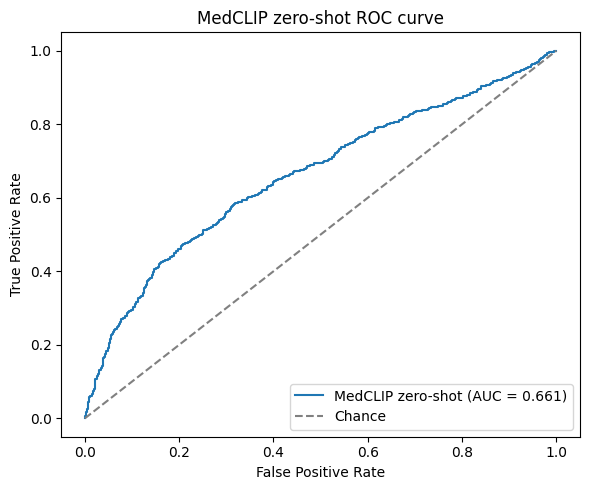

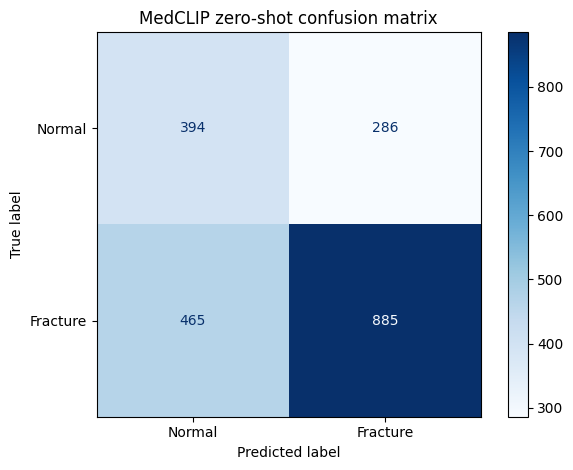

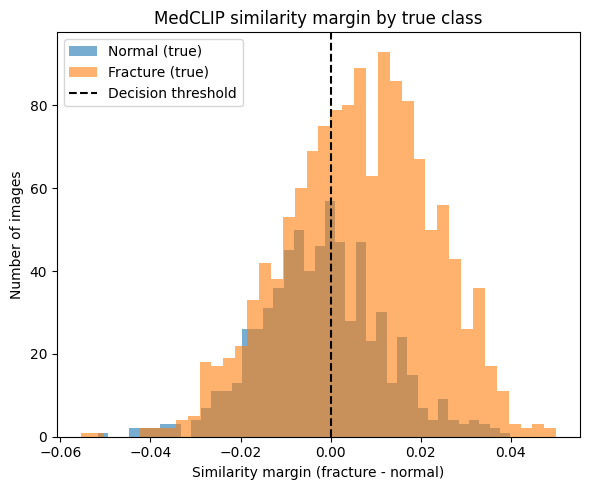

In [ ]:
fpr, tpr, _ = roc_curve(y_true, sim_margins)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"MedCLIP zero-shot (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("MedCLIP zero-shot ROC curve")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=["Normal", "Fracture"])
disp.plot(cmap="Blues", values_format="d")
plt.title("MedCLIP zero-shot confusion matrix")
plt.tight_layout()
plt.show()

margins = np.array(sim_margins)
y = np.array(y_true)

plt.figure(figsize=(6, 5))
plt.hist(margins[y == 0], bins=40, alpha=0.6, label="Normal (true)")
plt.hist(margins[y == 1], bins=40, alpha=0.6, label="Fracture (true)")
plt.axvline(0, color="black", linestyle="--", label="Decision threshold")
plt.xlabel("Similarity margin (fracture - normal)")
plt.ylabel("Number of images")
plt.title("MedCLIP similarity margin by true class")
plt.legend()
plt.tight_layout()
plt.show()

# Localization Consistency with Grad-CAM


In [ ]:
target_layer = model.layer4[-1]
cam = GradCAM(model=model, target_layers=[target_layer])

text_prompts = text_prompts_ensemble
IMG_SIZE = 224

full_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

consistency_scores_ensemble = []
consistency_labels_ensemble = []

def load_fracture_boxes(label_path, size=IMG_SIZE):
    boxes = []
    if not os.path.exists(label_path):
        return boxes
    with open(label_path) as f:
        for line in f:
            parts = line.split()
            if not parts or int(parts[0]) != 0:
                continue
            cx, cy, w, h = map(float, parts[1:5])
            boxes.append(((cx - w/2)*size, (cy - h/2)*size,
                          (cx + w/2)*size, (cy + h/2)*size))
    return boxes

loc_hits, loc_total = 0, 0
loc_energy = []

model.eval()
for batch_idx, (images, labels, paths) in enumerate(full_loader):

    images = images.to(device)
    label  = int(labels[0].item())

    output = model(images)
    prob   = torch.sigmoid(output).item()
    pred   = 1 if prob > 0.5 else 0

    grayscale_cam = cam(input_tensor=images,
                        targets=[BinaryClassifierOutputTarget(pred)])[0]

    img = images[0].cpu().numpy().transpose(1, 2, 0)
    img = np.clip(img * np.array(STD) + np.array(MEAN), 0, 1)

    medclip_probs  = run_medclip(img)
    fracture_score = medclip_probs[fracture_indices].mean()
    normal_score   = medclip_probs[normal_indices].mean()
    medclip_pred   = 1 if fracture_score > normal_score else 0

    consistency_scores_ensemble.append(int(pred == medclip_pred))
    consistency_labels_ensemble.append(label)


    if label == 1:
        label_path = os.path.join(
            TEST_LABEL_DIR,
            os.path.splitext(os.path.basename(paths[0]))[0] + ".txt"
        )
        boxes = load_fracture_boxes(label_path)
        if boxes:
            y_peak, x_peak = np.unravel_index(grayscale_cam.argmax(), grayscale_cam.shape)
            inside = any(x1 <= x_peak <= x2 and y1 <= y_peak <= y2
                         for (x1, y1, x2, y2) in boxes)
            loc_hits  += int(inside)
            loc_total += 1

            mask = np.zeros_like(grayscale_cam)
            for (x1, y1, x2, y2) in boxes:
                mask[int(max(0, y1)):int(y2), int(max(0, x1)):int(x2)] = 1
            denom = grayscale_cam.sum()
            if denom > 0:
                loc_energy.append(float((grayscale_cam * mask).sum() / denom))

    if batch_idx % 100 == 0:
        print(f"Image {batch_idx}/{len(full_loader)} processed")


Image 0/2030 processed
Image 100/2030 processed
Image 200/2030 processed
Image 300/2030 processed
Image 400/2030 processed
Image 500/2030 processed
Image 600/2030 processed
Image 700/2030 processed
Image 800/2030 processed
Image 900/2030 processed
Image 1000/2030 processed
Image 1100/2030 processed
Image 1200/2030 processed
Image 1300/2030 processed
Image 1400/2030 processed
Image 1500/2030 processed
Image 1600/2030 processed
Image 1700/2030 processed
Image 1800/2030 processed
Image 1900/2030 processed
Image 2000/2030 processed


In [ ]:
consistency_scores = np.array(consistency_scores_ensemble)
consistency_labels = np.array(consistency_labels_ensemble)

overall       = consistency_scores.mean() * 100
normal_cons   = consistency_scores[consistency_labels == 0].mean() * 100
fracture_cons = consistency_scores[consistency_labels == 1].mean() * 100


print("\n=== Grad-CAM LOCALIZATION vs. ground-truth fracture boxes ===")
if loc_total > 0:
    print(f"Fracture images evaluated: {loc_total}")
    print(f"Pointing-game hit rate:    {100*loc_hits/loc_total:.1f}%  "
          f"(Grad-CAM peak inside a GT fracture box)")
    print(f"Mean Grad-CAM energy in box: {100*np.mean(loc_energy):.1f}%")
    print("This measures whether the model actually attends to the fracture region.")
else:
    print("No fracture images with bounding boxes were found in the test set.")



=== Grad-CAM LOCALIZATION vs. ground-truth fracture boxes ===
Fracture images evaluated: 1350
Pointing-game hit rate:    42.9%  (Grad-CAM peak inside a GT fracture box)
Mean Grad-CAM energy in box: 12.6%
This measures whether the model actually attends to the fracture region.


In [ ]:
box_area_fracs = []
for fname, lab in zip(test_dataset.filenames, test_dataset.labels):
    if lab != 1:
        continue
    lp = os.path.join(TEST_LABEL_DIR, os.path.splitext(fname)[0] + ".txt")
    boxes = load_fracture_boxes(lp)
    if not boxes:
        continue
    mask = np.zeros((IMG_SIZE, IMG_SIZE), dtype=bool)
    for (x1, y1, x2, y2) in boxes:
        mask[int(max(0, y1)):int(y2), int(max(0, x1)):int(x2)] = True
    box_area_fracs.append(mask.mean())

chance = 100 * np.mean(box_area_fracs)
hit    = 100 * loc_hits / max(loc_total, 1)
energy = 100 * np.mean(loc_energy)

print("=== GRAD-CAM LOCALIZATION vs. CHANCE ===")
print(f"Fracture images with boxes:   {len(box_area_fracs)}")
print(f"Chance level (mean box area): {chance:.1f}%   <- random baseline")
print(f"Pointing-game hit rate:       {hit:.1f}%")
print(f"Lift over chance:             {hit / max(chance, 1e-9):.1f}x")
print(f"Mean Grad-CAM energy in box:  {energy:.1f}%   (chance = {chance:.1f}%)")

=== GRAD-CAM LOCALIZATION vs. CHANCE ===
Fracture images with boxes:   1350
Chance level (mean box area): 2.6%   <- random baseline
Pointing-game hit rate:       42.9%
Lift over chance:             16.5x
Mean Grad-CAM energy in box:  12.6%   (chance = 2.6%)


Collected 2 hits and 2 misses


/tmp/ipykernel_10335/3347535118.py:77: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter([x_peak], [y_peak], c="white", edgecolors="black",


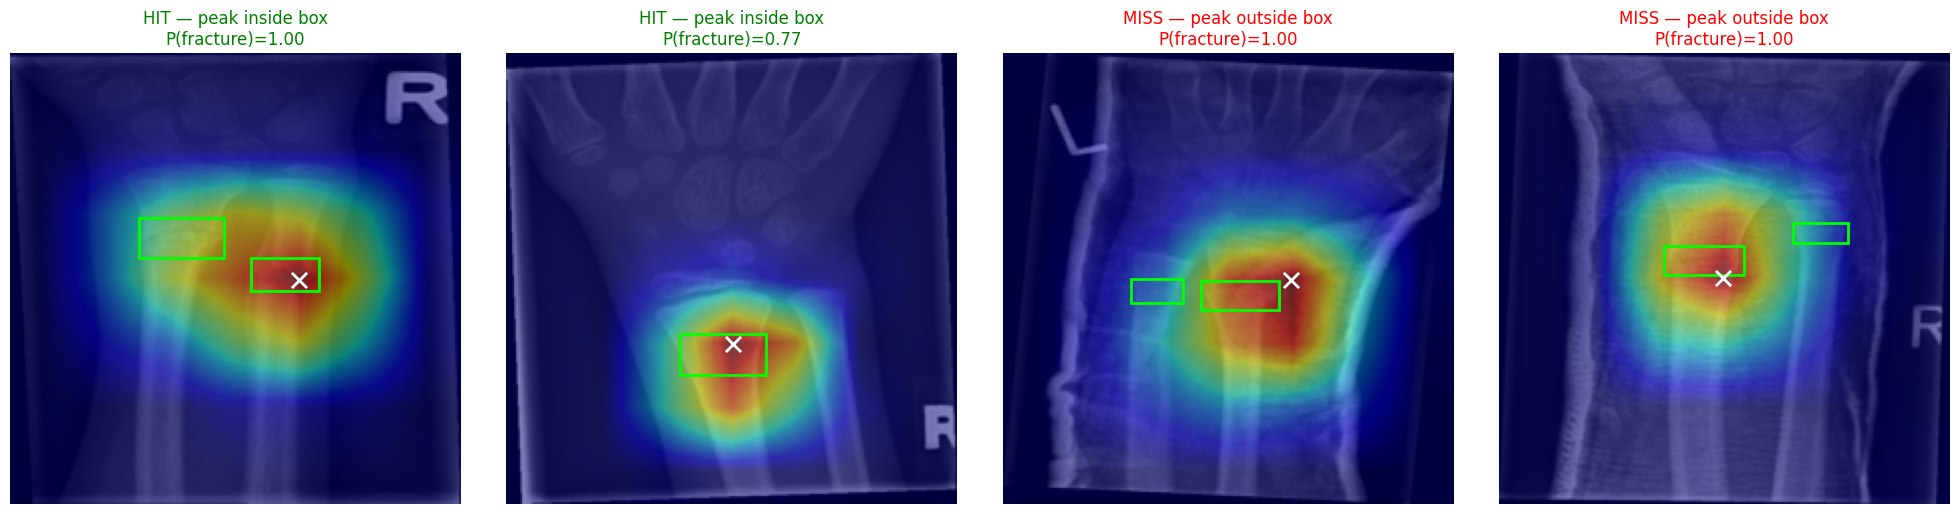

In [ ]:
IMG_SIZE = 224

def load_fracture_boxes(label_path, size=IMG_SIZE):
    boxes = []
    if not os.path.exists(label_path):
        return boxes
    with open(label_path) as f:
        for line in f:
            parts = line.split()
            if not parts or int(parts[0]) != 0:      # 0 == fracture
                continue
            cx, cy, w, h = map(float, parts[1:5])
            boxes.append(((cx - w/2)*size, (cy - h/2)*size,
                          (cx + w/2)*size, (cy + h/2)*size))
    return boxes


full_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

hits, misses = [], []
model.eval()

for images, labels, paths in full_loader:
    label = int(labels[0].item())
    if label != 1:
        continue

    label_path = os.path.join(
        TEST_LABEL_DIR,
        os.path.splitext(os.path.basename(paths[0]))[0] + ".txt"
    )
    boxes = load_fracture_boxes(label_path)
    if not boxes:
        continue

    images = images.to(device)
    output = model(images)
    prob   = torch.sigmoid(output).item()
    pred   = 1 if prob > 0.5 else 0

    grayscale_cam = cam(input_tensor=images,
                        targets=[BinaryClassifierOutputTarget(pred)])[0]


    y_peak, x_peak = np.unravel_index(grayscale_cam.argmax(), grayscale_cam.shape)
    inside = any(x1 <= x_peak <= x2 and y1 <= y_peak <= y2 for (x1, y1, x2, y2) in boxes)

    img = images[0].cpu().numpy().transpose(1, 2, 0)
    img = np.clip(img * np.array(STD) + np.array(MEAN), 0, 1)

    entry = (img, grayscale_cam, boxes, (x_peak, y_peak), prob)
    (hits if inside else misses).append(entry)

    if len(hits) >= 2 and len(misses) >= 2:
        break

print(f"Collected {len(hits)} hits and {len(misses)} misses")


examples = [(*h, "HIT")  for h in hits[:2]] + \
           [(*m, "MISS") for m in misses[:2]]

fig, axes = plt.subplots(1, len(examples), figsize=(5*len(examples), 5))

for ax, (img, cam_map, boxes, (x_peak, y_peak), prob, tag) in zip(axes, examples):
    ax.imshow(img)
    ax.imshow(cam_map, cmap="jet", alpha=0.5)


    for (x1, y1, x2, y2) in boxes:
        rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                 linewidth=2, edgecolor="lime", facecolor="none")
        ax.add_patch(rect)


    ax.scatter([x_peak], [y_peak], c="white", edgecolors="black",
               s=120, marker="x", linewidths=2)

    color = "green" if tag == "HIT" else "red"
    ax.set_title(f"{tag} — peak {'inside' if tag=='HIT' else 'outside'} box\n"
                 f"P(fracture)={prob:.2f}", color=color)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
IMG_SIZE = 224

def load_fracture_boxes(label_path, size=IMG_SIZE):
    """YOLO labels -> fracture (class 0) boxes as (x1,y1,x2,y2) on the size x size grid."""
    boxes = []
    if not os.path.exists(label_path):
        return boxes
    with open(label_path) as f:
        for line in f:
            parts = line.split()
            if not parts or int(parts[0]) != 0:      # 0 == fracture
                continue
            cx, cy, w, h = map(float, parts[1:5])
            boxes.append(((cx - w/2)*size, (cy - h/2)*size,
                          (cx + w/2)*size, (cy + h/2)*size))
    return boxes

def box_mask(boxes, size=IMG_SIZE):
    """Binary mask that is 1 inside any fracture box, 0 elsewhere."""
    mask = np.zeros((size, size), dtype=bool)
    for (x1, y1, x2, y2) in boxes:
        xi1, yi1 = int(np.floor(x1)), int(np.floor(y1))
        xi2, yi2 = int(np.ceil(x2)),  int(np.ceil(y2))
        xi1, yi1 = max(xi1, 0), max(yi1, 0)
        xi2, yi2 = min(xi2, size), min(yi2, size)
        mask[yi1:yi2, xi1:xi2] = True
    return mask

nt = NoiseTunnel(ig)

full_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

ig_energy = []
ig_hits, ig_total = 0, 0
chance_areas = []

model.eval()
for batch_idx, (images, labels, paths) in enumerate(full_loader):

    if int(labels[0].item()) != 1:
        continue

    label_path = os.path.join(
        TEST_LABEL_DIR,
        os.path.splitext(os.path.basename(paths[0]))[0] + ".txt"
    )
    boxes = load_fracture_boxes(label_path)
    if not boxes:
        continue

    images = images.to(device)


    baseline = TF.gaussian_blur(images, kernel_size=[11, 11], sigma=[5.0, 5.0]).to(device)
    attributions = nt.attribute(
        images,
        baselines=baseline,
        target=0,
        n_steps=15,
        nt_type="smoothgrad",
        nt_samples=8,
        stdevs=0.1,
    )


    attr = attributions.squeeze().detach().cpu().numpy().transpose(1, 2, 0)
    attr = np.abs(attr).sum(axis=2)

    mask = box_mask(boxes)

    total = attr.sum()
    if total > 0:
        ig_energy.append(attr[mask].sum() / total)


    y_peak, x_peak = np.unravel_index(attr.argmax(), attr.shape)
    ig_hits  += int(mask[y_peak, x_peak])
    ig_total += 1


    chance_areas.append(mask.mean())

    torch.cuda.empty_cache()

ig_energy    = np.array(ig_energy)
chance       = np.mean(chance_areas)
pointing     = ig_hits / ig_total

print("=== Improved IG LOCALIZATION vs. ground-truth fracture boxes ===")
print(f"Fracture images evaluated:      {ig_total}")
print(f"Chance level (mean box area):   {chance*100:.1f}%")
print(f"IG pointing-game hit rate:      {pointing*100:.1f}%   (lift {pointing/chance:.1f}x)")
print(f"Mean IG energy in box:          {ig_energy.mean()*100:.1f}%   (chance = {chance*100:.1f}%)")

=== Improved IG LOCALIZATION vs. ground-truth fracture boxes ===
Fracture images evaluated:      1350
Chance level (mean box area):   2.8%
IG pointing-game hit rate:      69.4%   (lift 25.1x)
Mean IG energy in box:          17.2%   (chance = 2.8%)


Collected 10 hits and 2 misses


/tmp/ipykernel_10335/843652317.py:91: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter([x_peak], [y_peak], c="white", edgecolors="black",


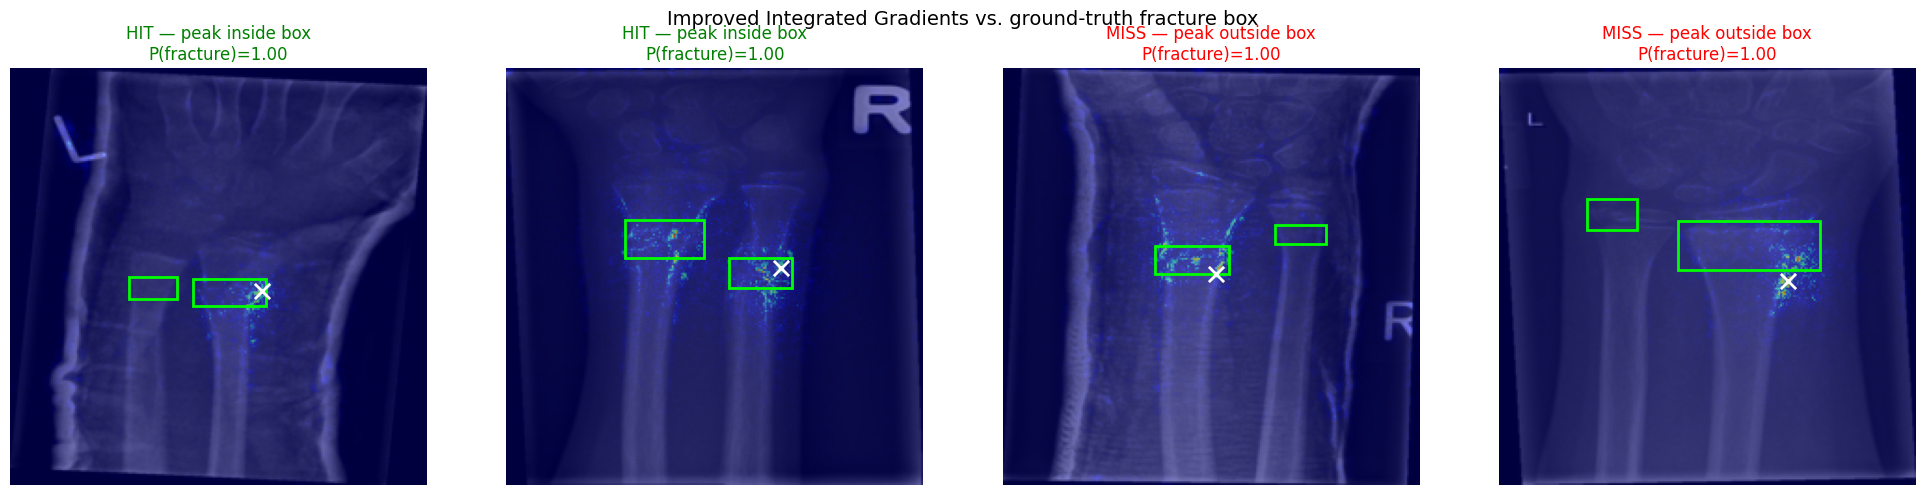

In [ ]:
IMG_SIZE = 224

def load_fracture_boxes(label_path, size=IMG_SIZE):
    """YOLO labels -> fracture (class 0) boxes as (x1,y1,x2,y2) on the size x size grid."""
    boxes = []
    if not os.path.exists(label_path):
        return boxes
    with open(label_path) as f:
        for line in f:
            parts = line.split()
            if not parts or int(parts[0]) != 0:      # 0 == fracture
                continue
            cx, cy, w, h = map(float, parts[1:5])
            boxes.append(((cx - w/2)*size, (cy - h/2)*size,
                          (cx + w/2)*size, (cy + h/2)*size))
    return boxes

def box_mask(boxes, size=IMG_SIZE):
    mask = np.zeros((size, size), dtype=bool)
    for (x1, y1, x2, y2) in boxes:
        xi1, yi1 = max(int(np.floor(x1)), 0), max(int(np.floor(y1)), 0)
        xi2, yi2 = min(int(np.ceil(x2)), size), min(int(np.ceil(y2)), size)
        mask[yi1:yi2, xi1:xi2] = True
    return mask


nt = NoiseTunnel(ig)

full_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

hits, misses = [], []
model.eval()

for images, labels, paths in full_loader:
    if int(labels[0].item()) != 1:
        continue

    label_path = os.path.join(
        TEST_LABEL_DIR,
        os.path.splitext(os.path.basename(paths[0]))[0] + ".txt"
    )
    boxes = load_fracture_boxes(label_path)
    if not boxes:
        continue

    images = images.to(device)
    prob   = torch.sigmoid(model(images)).item()


    baseline = TF.gaussian_blur(images, kernel_size=[11, 11], sigma=[5.0, 5.0]).to(device)
    attributions = nt.attribute(
        images, baselines=baseline, target=0,
        n_steps=15, nt_type="smoothgrad", nt_samples=8, stdevs=0.1,
    )
    attr = attributions.squeeze().detach().cpu().numpy().transpose(1, 2, 0)
    attr = np.abs(attr).sum(axis=2)
    attr = (attr - attr.min()) / (attr.max() - attr.min() + 1e-8)


    mask = box_mask(boxes)
    y_peak, x_peak = np.unravel_index(attr.argmax(), attr.shape)
    inside = bool(mask[y_peak, x_peak])

    img = images[0].cpu().numpy().transpose(1, 2, 0)
    img = np.clip(img * np.array(STD) + np.array(MEAN), 0, 1)

    entry = (img, attr, boxes, (x_peak, y_peak), prob)
    (hits if inside else misses).append(entry)

    torch.cuda.empty_cache()
    if len(hits) >= 2 and len(misses) >= 2:
        break

print(f"Collected {len(hits)} hits and {len(misses)} misses")

examples = [(*h, "HIT")  for h in hits[:2]] + \
           [(*m, "MISS") for m in misses[:2]]

fig, axes = plt.subplots(1, len(examples), figsize=(5*len(examples), 5))
fig.suptitle("Improved Integrated Gradients vs. ground-truth fracture box", fontsize=14)

for ax, (img, ig_map, boxes, (x_peak, y_peak), prob, tag) in zip(axes, examples):
    ax.imshow(img)
    ax.imshow(ig_map, cmap="jet", alpha=0.5)

    for (x1, y1, x2, y2) in boxes:
        rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                 linewidth=2, edgecolor="lime", facecolor="none")
        ax.add_patch(rect)

    ax.scatter([x_peak], [y_peak], c="white", edgecolors="black",
               s=120, marker="x", linewidths=2)

    color = "green" if tag == "HIT" else "red"
    ax.set_title(f"{tag} — peak {'inside' if tag=='HIT' else 'outside'} box\n"
                 f"P(fracture)={prob:.2f}", color=color)
    ax.axis("off")

plt.tight_layout()
plt.show()

# Diagnosis Reports

Batch 0/64 completed
Batch 10/64 completed
Batch 20/64 completed
Batch 30/64 completed
Batch 40/64 completed
Batch 50/64 completed
Batch 60/64 completed

Reports generated: 141
Saved in: /content/reports


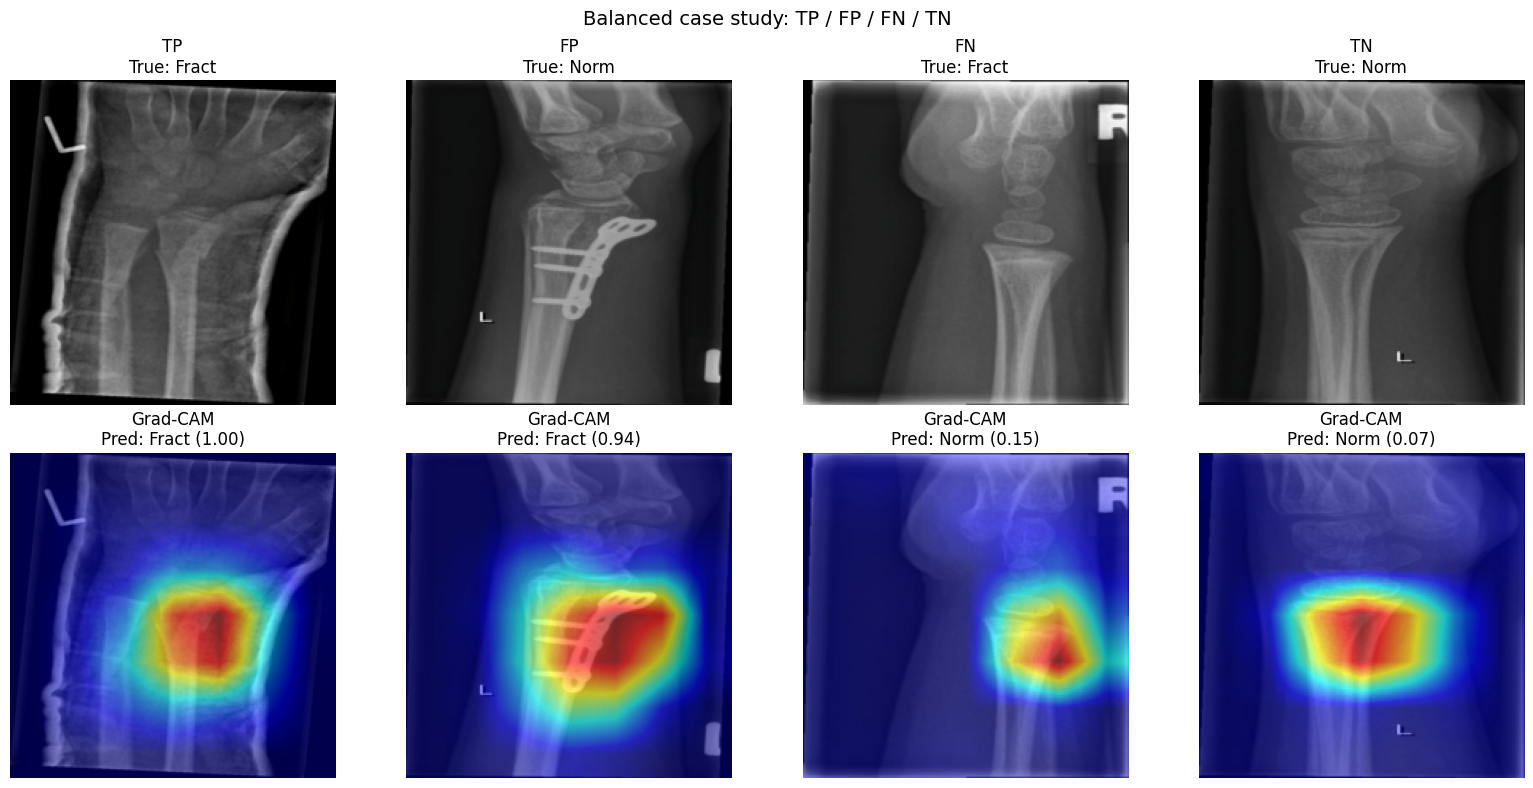

################  TP  ################

WRIST FRACTURE DETECTION - DIAGNOSTIC REPORT
Image: 0014_0516192795_01_WRI-L1_M006_png.rf.1bfee79f6e05d327665b19f691487d6a.jpg

CLASSIFICATION RESULT:
- Diagnosis:      Fracture detected
- Confidence:     1.00
- Ground Truth:   Fracture (confirmed)
- Case:           TRUE POSITIVE - Correct detection

MEDCLIP SEMANTIC INTERPRETATION:
- MedCLIP prediction:  Fracture
- Fracture score:      0.170
- Normal score:        0.163
- Most relevant text:  "Distal radius fracture with visible cortical disruption and fracture line"

CONSISTENCY:
- ResNet and MedCLIP agree: YES

VISUAL EXPLANATION:
- Grad-CAM highlights the region most influential for the prediction
- Integrated Gradients shows pixel-level attribution map

################  FP  ################

WRIST FRACTURE DETECTION - DIAGNOSTIC REPORT
Image: 0139_0818356754_04_WRI-L2_M016_png.rf.396bab7bb489498c5005ba26de9c07ac.jpg

CLASSIFICATION RESULT:
- Diagnosis:      Fracture detected
- Confidence:  

In [ ]:
text_prompts = text_prompts_ensemble
REPORT_DIR = "/content/reports"
os.makedirs(REPORT_DIR, exist_ok=True)

def generate_report(pred, prob, label, medclip_probs, path):

    if pred == 1:
        diagnosis = "Fracture detected"
    else:
        diagnosis = "No fracture detected"

    if label == 1:
        ground_truth = "Fracture (confirmed)"
    else:
        ground_truth = "Normal (confirmed)"

    if pred == 1 and label == 1:
        case = "TRUE POSITIVE - Correct detection"
    elif pred == 1 and label == 0:
        case = "FALSE POSITIVE - Incorrect detection"
    elif pred == 0 and label == 0:
        case = "TRUE NEGATIVE - Correct exclusion"
    else:
        case = "FALSE NEGATIVE - Missed fracture"

    fracture_score = medclip_probs[fracture_indices].mean()
    normal_score   = medclip_probs[normal_indices].mean()
    medclip_pred   = "Fracture" if fracture_score > normal_score else "Normal"

    best_idx  = medclip_probs.argmax()
    best_text = text_prompts_ensemble[best_idx]

    report = f"""
====================================================
WRIST FRACTURE DETECTION - DIAGNOSTIC REPORT
====================================================
Image: {os.path.basename(path)}

CLASSIFICATION RESULT:
- Diagnosis:      {diagnosis}
- Confidence:     {prob:.2f}
- Ground Truth:   {ground_truth}
- Case:           {case}

MEDCLIP SEMANTIC INTERPRETATION:
- MedCLIP prediction:  {medclip_pred}
- Fracture score:      {fracture_score:.3f}
- Normal score:        {normal_score:.3f}
- Most relevant text:  "{best_text}"

CONSISTENCY:
- ResNet and MedCLIP agree: {"YES" if (pred == 1) == (fracture_score > normal_score) else "NO"}

VISUAL EXPLANATION:
- Grad-CAM highlights the region most influential for the prediction
- Integrated Gradients shows pixel-level attribution map
====================================================
"""
    return report

model.eval()
reports_generated = 0

for batch_idx, (images, labels, paths) in enumerate(test_loader):

    images = images.to(device)
    labels = labels.float().to(device)

    with torch.no_grad():
        outputs = model(images)
        probs   = torch.sigmoid(outputs).squeeze(1)
        preds   = (probs > 0.5).float()

    for i in range(images.size(0)):

        prob  = probs[i].item()
        pred  = int(preds[i].item())
        label = int(labels[i].item())

        if pred == label:
            continue

        img = images[i].cpu().numpy().transpose(1, 2, 0)
        img = img * np.array(STD) + np.array(MEAN)
        img = np.clip(img, 0, 1)

        medclip_probs = run_medclip(img)

        report = generate_report(pred, prob, label, medclip_probs, paths[i])

        base      = os.path.splitext(os.path.basename(paths[i]))[0]
        save_name = f"report_pred{pred}_true{label}_prob{prob:.2f}_{base}.txt"
        with open(os.path.join(REPORT_DIR, save_name), "w") as f:
            f.write(report)

        reports_generated += 1

    if batch_idx % 10 == 0:
        print(f"Batch {batch_idx}/{len(test_loader)} completed")

print(f"\nReports generated: {reports_generated}")
print(f"Saved in: {REPORT_DIR}")


text_prompts = text_prompts_ensemble
wanted   = ["TP", "FP", "FN", "TN"]
examples = {}

model.eval()
for images, labels, paths in test_loader:
    images = images.to(device)
    with torch.no_grad():
        probs = torch.sigmoid(model(images)).squeeze(1)
        preds = (probs > 0.5).float()
    for i in range(images.size(0)):
        pred, label = int(preds[i].item()), int(labels[i].item())
        case = ("TP" if (pred == 1 and label == 1) else
                "FP" if (pred == 1 and label == 0) else
                "TN" if (pred == 0 and label == 0) else "FN")
        if case in wanted and case not in examples:
            examples[case] = {"img_tensor": images[i].detach().clone(),
                              "prob": probs[i].item(), "pred": pred,
                              "label": label, "path": paths[i]}
    if all(k in examples for k in wanted):
        break

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle("Balanced case study: TP / FP / FN / TN", fontsize=14)
for col, case in enumerate(wanted):
    if case not in examples:
        axes[0, col].axis("off"); axes[1, col].axis("off"); continue
    ex   = examples[case]
    x    = ex["img_tensor"].unsqueeze(0).to(device)
    gcam = cam(input_tensor=x, targets=[BinaryClassifierOutputTarget(ex["pred"])])[0]
    img  = np.clip(ex["img_tensor"].cpu().numpy().transpose(1, 2, 0) * np.array(STD) + np.array(MEAN), 0, 1)
    vis  = show_cam_on_image(img.astype(np.float32), gcam, use_rgb=True)
    axes[0, col].imshow(img); axes[0, col].axis("off")
    axes[0, col].set_title(f"{case}\nTrue: {'Fract' if ex['label']==1 else 'Norm'}")
    axes[1, col].imshow(vis); axes[1, col].axis("off")
    axes[1, col].set_title(f"Grad-CAM\nPred: {'Fract' if ex['pred']==1 else 'Norm'} ({ex['prob']:.2f})")
plt.tight_layout(); plt.show()

for case in wanted:
    if case not in examples:
        print(f"(no {case} example found in the test set)\n"); continue
    ex  = examples[case]
    img = np.clip(ex["img_tensor"].cpu().numpy().transpose(1, 2, 0) * np.array(STD) + np.array(MEAN), 0, 1)
    print(f"################  {case}  ################")
    print(generate_report(ex["pred"], ex["prob"], ex["label"], run_medclip(img), ex["path"]))